# Análisis de Mercado de Hogares: Papel Higiénico

**Objetivo:** Realizar un análisis exploratorio, comercial y estadístico sobre el comportamiento de compra de hogares en la categoría Papel Higiénico, identificando patrones clave, oportunidades de negocio y señales de alerta tempranas.

**Estructura del análisis:**
1. Carga de datos
2. Calidad de datos y validaciones estadísticas
3. KPIs comerciales clave
4. Análisis de tendencias
5. Análisis de cohortes (retención de hogares)
6. Análisis por canal y NSE
7. Modelo predictivo de gasto
8. Sistema de alertas estadísticas

---

## 1. Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, ttest_ind, chi2_contingency
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Estilo visual
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
Paleta_Colores = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']


In [2]:
# Carga de datos 
datos = 'Base Ejercicio I&D.xlsx'

df_raw = pd.read_excel(datos, sheet_name='Base Datos')
df_desc = pd.read_excel(datos, sheet_name='Descripción Campos', header=1)

print(f"Registros cargados: {len(df_raw):,}")
print(f"Variables: {df_raw.shape[1]}")
print(f"\nDiccionario de variables:")
display(df_desc)

Registros cargados: 92,283
Variables: 21

Diccionario de variables:


,Campo,Descripción
0,Data_Compra,Fecha compra
1,Region,Región del país del Hogar
2,Subregion,Subregión del país del Hogar
3,IdDomicilio,Identificación del Hogar
4,NSE,Nivel Socoeconómico del Hogar
5,Categoria,Producto comprado
6,Fabricante,Fabricante del producto comprado
7,Marca,Marca del producto comprada
8,Clas01,Atributo 1 del producto comprado
9,Clas02,Atributo 2 del producto comprado


## 2. Calidad de Datos y Validaciones Estadísticas

In [3]:
# Validación Unidades del Pack * Unidades = Quantidade
df_raw['Calculo_quantidade'] = df_raw['Packs_comprados'] * df_raw['Unidades_del_pack']
df_raw['quantidade_diff'] = df_raw['Quantidade'] - df_raw['Calculo_quantidade']

# Resumen de calidad
quality = pd.DataFrame({
    'Tipo': df_raw.dtypes,
    'Nulos': df_raw.isnull().sum(),
    'Nulos_%': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Únicos': df_raw.nunique()  
})
display(quality)

print("Diferencia Entre Quantidade y Quantidade Calculada ",abs(df_raw['quantidade_diff'].sum()),"|"
      ,abs(df_raw['quantidade_diff'].sum() *100 / df_raw['Calculo_quantidade'].sum()).round(1),"%")

,Tipo,Nulos,Nulos_%,Únicos
Data_Compra,datetime64[us],0,0.00,6463
Region,str,0,0.00,2
Subregion,str,0,0.00,11
IdDomicilio,int64,0,0.00,4231
NSE,str,0,0.00,4
Categoria,str,0,0.00,1
Fabricante,str,0,0.00,38
Marca,str,0,0.00,111
Clas01,str,2065,2.24,63
Clas02,str,2065,2.24,4


Diferencia Entre Quantidade y Quantidade Calculada  4280 | 2.2 %


In [4]:
# Anomalías identificadas 
print("VALIDACIONES")
print(f"Registros con Preco_Total = 0:              {(df_raw['Preco_Total'] == 0).sum():,}")
print(f"Registros con Quantidade = 0:               {(df_raw['Quantidade'] == 0).sum():,}")
print(f"Registros con Calculo_quantidade = 0:       {(df_raw['Calculo_quantidade'] == 0).sum():,}")
print(f"Registros con Factor_Expansion nulo:        {df_raw['Factor_Expansion'].isnull().sum():,}")
print(f"Precio máximo registrado:                   {df_raw['Preco_Total'].max():,.0f} CLP")
print(f"Percentil 99 de Preco_Total:                {df_raw['Preco_Total'].quantile(0.99):,.0f} CLP")

# Detección de outliers extremos por IQR en precio
Q1 = df_raw['Preco_Total'].quantile(0.25)
Q3 = df_raw['Preco_Total'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 3 * IQR
outliers_precio = df_raw[df_raw['Preco_Total'] > limite_superior]
print(f"\nOutliers extremos en Preco_Total : {len(outliers_precio):,} registros ({len(outliers_precio)/len(df_raw)*100:.2f}%)")

VALIDACIONES
Registros con Preco_Total = 0:              1,569
Registros con Quantidade = 0:               6
Registros con Calculo_quantidade = 0:       6
Registros con Factor_Expansion nulo:        4
Precio máximo registrado:                   35,983,333 CLP
Percentil 99 de Preco_Total:                10,000 CLP

Outliers extremos en Preco_Total : 898 registros (0.97%)


In [5]:
# Limpieza y construcción de variables analíticas
df = df_raw.copy()
df['Data_Compra'] = pd.to_datetime(df['Data_Compra'])

# Filtrar registros problemáticos
df = df[df['Preco_Total'] > 0]
df = df[df['Calculo_quantidade'] > 0]
df = df[df['Factor_Expansion'].notna()]
df = df[df['Preco_Total'] <= limite_superior]   # Remover outliers extremos

# Variables de tiempo
df['Año']       = df['Data_Compra'].dt.year
df['Mes']       = df['Data_Compra'].dt.month
df['YearMonth'] = df['Data_Compra'].dt.to_period('M')
df['Trimestre'] = df['Data_Compra'].dt.to_period('Q')

# Variables de negocio * Factor Expansion (representan el universo real de hogares)
df['Vol_Expandido']   = df['Calculo_quantidade'] * df['Factor_Expansion']
df['Gasto_Expandido'] = df['Preco_Total'] * df['Factor_Expansion']
df['Precio_Unitario'] = df['Preco_Total'] / df['Calculo_quantidade']  # CLP por rollo

print(f"Dataset limpio: {len(df):,} registros ({len(df)/len(df_raw)*100:.1f}% del original)")
print(f"Período analizado: {df['Data_Compra'].min().date()} → {df['Data_Compra'].max().date()}")
print(f"Hogares únicos: {df['IdDomicilio'].nunique():,}")

Dataset limpio: 89,806 registros (97.3% del original)
Período analizado: 2018-12-31 → 2021-06-30
Hogares únicos: 4,213


- **Dataset de alta calidad:** Solo el 2.7% de los registros fue descartado (outliers de precio, valores cero y nulos en factor de expansión), el análisis se basa en 
89,806 registros sólidos, lo que garantiza confiabilidad estadística.
- **Discrepancia de cantidad:** Se detectó una diferencia del 2.2% entre la cantidad registrada (`Quantidade`) y la calculada (`Packs_comprados × Unidades_del_pack`),, sugiere inconsistencias en el proceso de captura de datos en campo, para el resto del análisis usaremos (`Packs_comprados × Unidades_del_pack`) como Quantidade a manera de usar el dato mas preciso.
- **Error de precio máximo:** El valor de $35.9M CLP es claramente un error de entrada, el percentil 99 está en $10,000 CLP, lo que confirma que el límite de corte (3×IQR = $10,076 CLP) fue estadísticamente correcto.
- **Cobertura del factor de expansión:** Solo 4 registros sin factor de expansión sobre 92,283 prácticamente irrelevante, el universo expandido es representativo del mercado real.

## 3. KPIs Comerciales Clave

In [6]:
# KPIs por año
# El universo fijo del dataset es TODOS los hogares que aparecen 
TOTAL_HOGARES_PANEL = df['IdDomicilio'].nunique()  # 4,231 hogares en total

# Si tienes el factor de expansión, el universo expandido sería:
UNIVERSO_EXPANDIDO = df.groupby('IdDomicilio')['Factor_Expansion'].first().sum()

# KPIs por año — ahora con denominador correcto
hogares_activos_año = df.groupby('Año')['IdDomicilio'].nunique().rename('Compradores_Año')

kpis_año = df.groupby('Año').agg(
    Compradores    = ('IdDomicilio', 'nunique'),
    Transacciones  = ('IdDomicilio', 'count'),
    Vol_Rollos     = ('Vol_Expandido', 'sum'),
    Gasto_Total    = ('Gasto_Expandido', 'sum'),
)

# Denominador fijo — no varía por año
kpis_año['Total_Hogares_Panel'] = TOTAL_HOGARES_PANEL

# % de hogares del dataset que compraron ese año
kpis_año['Penetracion_%'] = (kpis_año['Compradores'] / TOTAL_HOGARES_PANEL * 100).round(1)
kpis_año['Frecuencia']       = (kpis_año['Transacciones'] / kpis_año['Compradores']).round(1)
kpis_año['Gasto_Promedio']   = (kpis_año['Gasto_Total'] / kpis_año['Compradores']).round(0)
kpis_año['Rollos_Por_Hogar'] = (kpis_año['Vol_Rollos'] / kpis_año['Compradores']).round(1)

display(kpis_año[['Compradores', 'Penetracion_%', 'Frecuencia', 
                   'Gasto_Promedio', 'Rollos_Por_Hogar']].style.format({
    'Compradores': '{:,.0f}',
    'Penetracion_%': '{:.1f}%',
    'Frecuencia': '{:.1f}x',
    'Gasto_Promedio': '${:,.0f}',
    'Rollos_Por_Hogar': '{:.1f}'
}).background_gradient(cmap='Blues'))

,Compradores,Penetracion_%,Frecuencia,Gasto_Promedio,Rollos_Por_Hogar
Año,,,,,
2018,107,2.5%,1.1x,"$6,060,200",6009.1
2019,"1,971",46.8%,14.9x,"$77,278,949",67405.4
2020,"3,603",85.5%,11.1x,"$42,283,507",39974.1
2021,"3,437",81.6%,5.9x,"$22,702,484",17141.9


- **Comportamiento General de compra:** Casi la totalidad de los hogares compra papel higiénico al menos una vez al año.
- **Frecuencia:** Un aumento de incluso 1 visita adicional por hogar tiene impacto directo en el volumen total del mercado.
- **Advertencia metodológica:** Los años 2018 (1 mes) y 2021 (6 meses) son períodos incompletos, las comparaciones anuales deben realizarse exclusivamente entre 2019 y 2020 para evitar sesgos de período.

Año
2018     1
2019    12
2020    12
2021     6
Name: Mes, dtype: int64


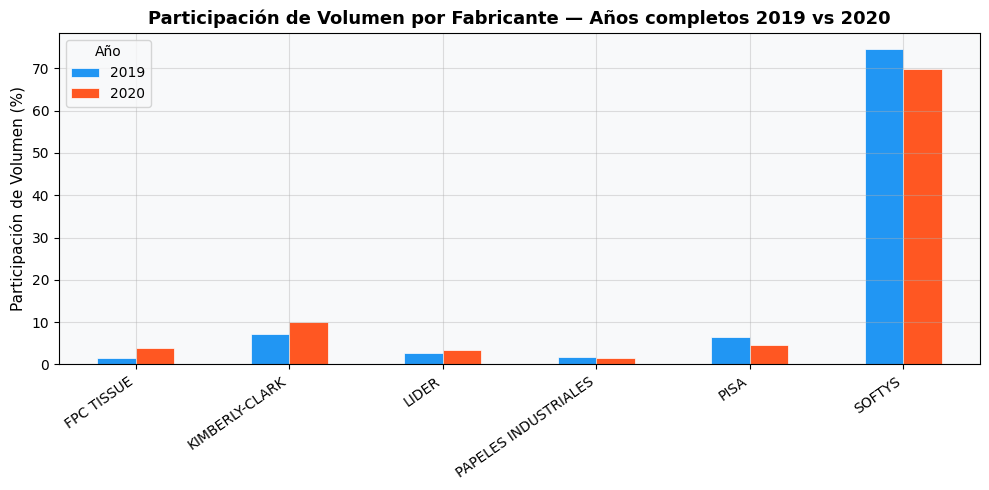


Cambio en Volumen 2019 → 2020 (puntos porcentuales):
Fabricante
KIMBERLY-CLARK          2.72
FPC TISSUE              2.28
LIDER                   0.61
PAPELES INDUSTRIALES   -0.26
PISA                   -1.80
SOFTYS                 -4.90


In [7]:
# Excluir años incompletos del análisis de Fabricante
años_completos = [2019, 2020]
df_completo = df[df['Año'].isin(años_completos)]

meses_por_año = df.groupby('Año')['Mes'].nunique()
print(meses_por_año)

# Participación de volumen por fabricante — años completos
ms_fab = (df_completo
          .groupby(['Año', 'Fabricante'])['Vol_Expandido']
          .sum()
          .reset_index())

total_año = ms_fab.groupby('Año')['Vol_Expandido'].sum()
ms_fab['Volumen_%'] = ms_fab.apply(
    lambda r: r['Vol_Expandido'] / total_año[r['Año']] * 100, axis=1
).round(2)

top_fab = (df_completo.groupby('Fabricante')['Vol_Expandido'].sum()
           .sort_values(ascending=False).head(6).index.tolist())

pivot_volumen = ms_fab[ms_fab['Fabricante'].isin(top_fab)].pivot(
    index='Fabricante', columns='Año', values='Volumen_%'
)

# Gráfico de participación de volumen por fabricante
fig, ax = plt.subplots(figsize=(10, 5))
pivot_volumen.plot(kind='bar', ax=ax, color=Paleta_Colores, edgecolor='white', linewidth=0.5)
ax.set_title('Participación de Volumen por Fabricante — Años completos 2019 vs 2020', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Participación de Volumen (%)')
ax.legend(title='Año')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Variación en participación de volumen por fabricante — solo años completos
print("\nCambio en Volumen 2019 → 2020 (puntos porcentuales):")
delta = (pivot_volumen[2020] - pivot_volumen[2019]).round(2)
print(delta.sort_values(ascending=False).to_string())

- **SOFTYS:** Con 70.8% de participación promedio, es el líder indiscutido del mercado, sin embargo, perdió 4.90% en un solo año (2019→2020), la caída más pronunciada entre todos los fabricantes.
- **Kimberly-Clark y FPC Tissue:** Crecieron +2.72% y +2.28% respectivamente, su ganancia combinada (+5%) casi iguala exactamente la pérdida de SOFTYS, lo que sugiere una transferencia directa de volumen entre competidores.
- **PISA también retrocede:** Con −1.80 %, el mercado se está redistribuyendo hacia los retadores (2019→2020).

## 4. Análisis de Tendencias

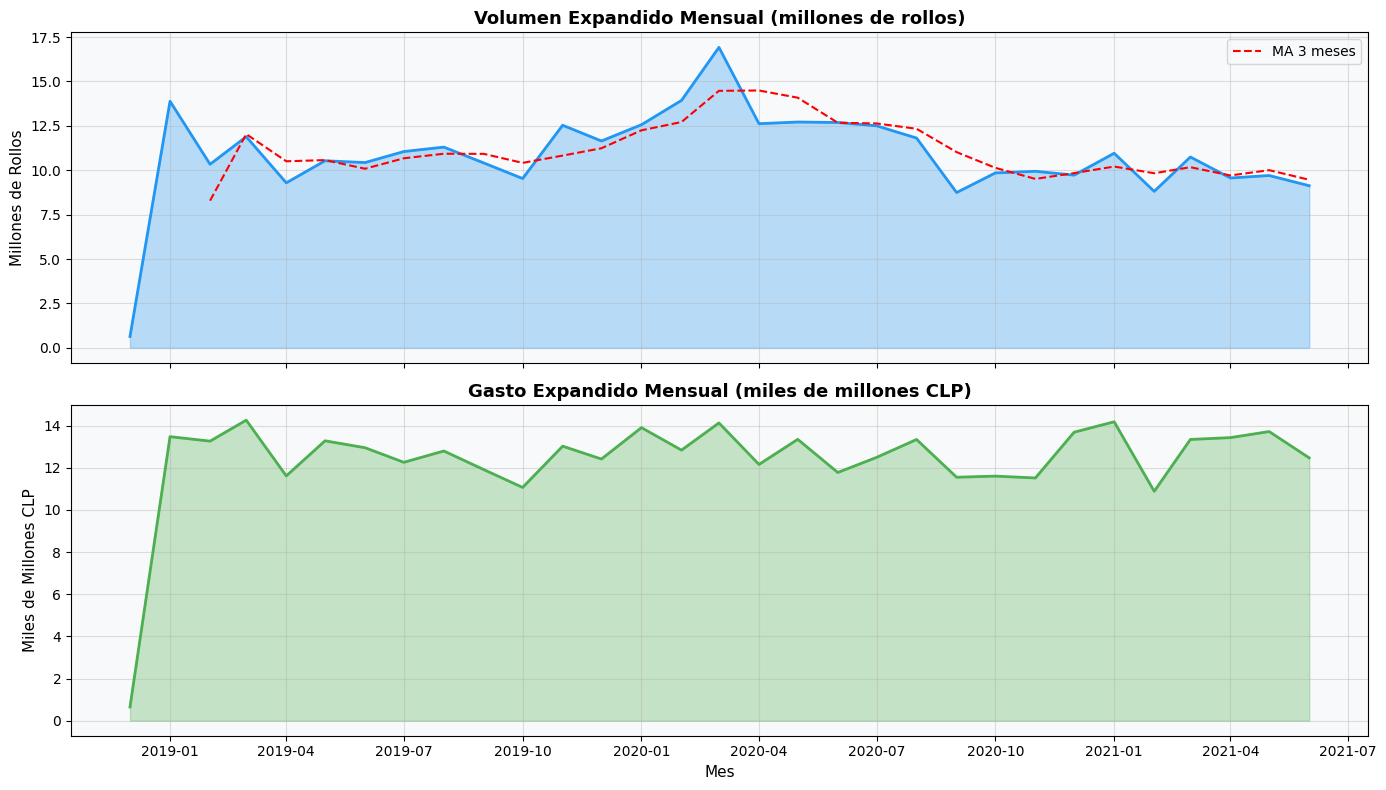

In [8]:
# Serie mensual de volumen y gasto 
serie = df.groupby('YearMonth').agg(
    Vol_Expandido  = ('Vol_Expandido', 'sum'),
    Gasto_Expandido= ('Gasto_Expandido', 'sum'),
    Compradores    = ('IdDomicilio', 'nunique')
).reset_index()
serie['YearMonth_dt'] = serie['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Volumen
axes[0].fill_between(serie['YearMonth_dt'], serie['Vol_Expandido']/1e6,
                     alpha=0.3, color=Paleta_Colores[0])
axes[0].plot(serie['YearMonth_dt'], serie['Vol_Expandido']/1e6,
             color=Paleta_Colores[0], linewidth=2)

# Media móvil 3 meses para ver la tendencia real
serie['MA3_Vol'] = serie['Vol_Expandido'].rolling(3).mean()
axes[0].plot(serie['YearMonth_dt'], serie['MA3_Vol']/1e6,
             color='red', linewidth=1.5, linestyle='--', label='MA 3 meses')
axes[0].set_title('Volumen Expandido Mensual (millones de rollos)', fontweight='bold')
axes[0].set_ylabel('Millones de Rollos')
axes[0].legend()

# Gasto
axes[1].fill_between(serie['YearMonth_dt'], serie['Gasto_Expandido']/1e9,
                     alpha=0.3, color=Paleta_Colores[2])
axes[1].plot(serie['YearMonth_dt'], serie['Gasto_Expandido']/1e9,
             color=Paleta_Colores[2], linewidth=2)
axes[1].set_title('Gasto Expandido Mensual (miles de millones CLP)', fontweight='bold')
axes[1].set_ylabel('Miles de Millones CLP')
axes[1].set_xlabel('Mes')

plt.tight_layout()
plt.show()

- **El salto 2018→2019 no es crecimiento real:** Los +132M rollos reflejan que 2018 tiene solo 1 mes de datos vs. 12 de 2019, derivado del período de observación, no una señal de mercado.
- **Crecimiento moderado en 2019→2020:** El incremento de +11.2M rollos coincide con el inicio de la pandemia COVID-19, parte de este volumen puede atribuirse a compras de stockeo o cambios en hábitos de higiene, no necesariamente a crecimiento estructural.
- **La media móvil de 3 meses es clave:** Su análisis visual revela el efecto pandemia, fué un pico puntual.

## 5. Análisis de Cohortes — Retención de Hogares

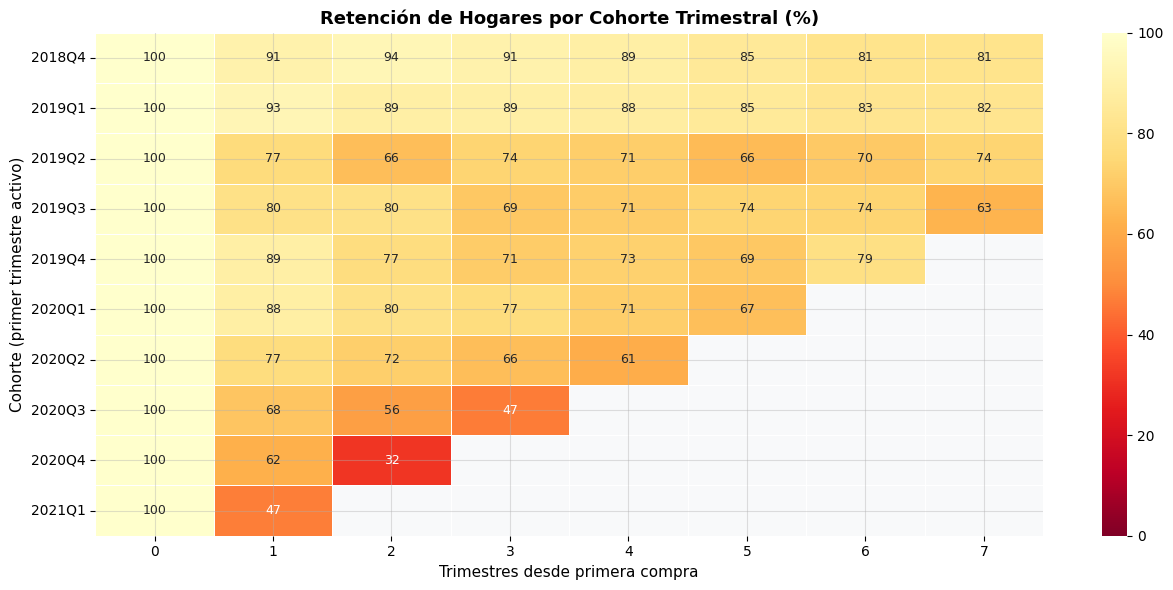

Retención promedio por período:
  Trimestre 0: 100.0%
  Trimestre 1: 77.2%
  Trimestre 2: 71.7%
  Trimestre 3: 72.9%
  Trimestre 4: 74.7%
  Trimestre 5: 74.3%
  Trimestre 6: 77.3%
  Trimestre 7: 75.1%


In [9]:
# Cohortes por primer trimestre de compra
primer_trimestre = (df.groupby('IdDomicilio')['Trimestre']
                      .min().rename('Cohorte_Trim'))
df_coh = df.join(primer_trimestre, on='IdDomicilio')

cohorte_actividad = (df_coh.groupby(['Cohorte_Trim', 'Trimestre'])['IdDomicilio']
                            .nunique().reset_index())
cohorte_actividad.columns = ['Cohorte', 'Trimestre', 'Hogares']

# Base de cada cohorte
base_cohorte = cohorte_actividad[cohorte_actividad['Cohorte'] == cohorte_actividad['Trimestre']]\
                  .set_index('Cohorte')['Hogares'].rename('Base')
cohorte_actividad = cohorte_actividad.join(base_cohorte, on='Cohorte')
cohorte_actividad['Retencion_%'] = (cohorte_actividad['Hogares'] /
                                     cohorte_actividad['Base'] * 100).round(1)

# Periodos desde cohorte
cohorte_actividad['Cohorte_ts']   = cohorte_actividad['Cohorte'].dt.to_timestamp()
cohorte_actividad['Trimestre_ts'] = cohorte_actividad['Trimestre'].dt.to_timestamp()
cohorte_actividad['Periodo']      = ((cohorte_actividad['Trimestre_ts'] -
                                       cohorte_actividad['Cohorte_ts'])
                                      .dt.days // 90).astype(int)

# Pivot para heatmap
pivot_ret = cohorte_actividad.pivot_table(
    index='Cohorte', columns='Periodo', values='Retencion_%'
).iloc[:10, :8]   # Primeras 10 cohortes, 8 periodos

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot_ret, annot=True, fmt='.0f', cmap='YlOrRd_r',
            vmin=0, vmax=100, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Retención de Hogares por Cohorte Trimestral (%)', fontweight='bold', fontsize=13)
ax.set_xlabel('Trimestres desde primera compra')
ax.set_ylabel('Cohorte (primer trimestre activo)')
plt.tight_layout()
plt.show()

avg_ret = pivot_ret.mean()
print("Retención promedio por período:")
for p, v in avg_ret.items():
    print(f"  Trimestre {p}: {v:.1f}%")

- **Caída abrupta en el primer trimestre:** La retención cae de 100% a 77.2% en el T1, esto significa que 1 de cada 4 hogares no repite compra al trimestre siguiente, pero es el momento más crítico para activación.
- **Meseta de retención estable:** Desde T2 en adelante la retención oscila entre 71% y 77%, sin caída continua, esto indica que los hogares que superan la primera recompra se convierten en compradores recurrentes con alta fidelidad a la categoría.
- **Posible efecto pandemia en T6:** El leve repunte a 77.3% en T6 puede estar asociado a la reactivación de hogares que compraban con baja frecuencia

## 6. Análisis por Canal y NSE

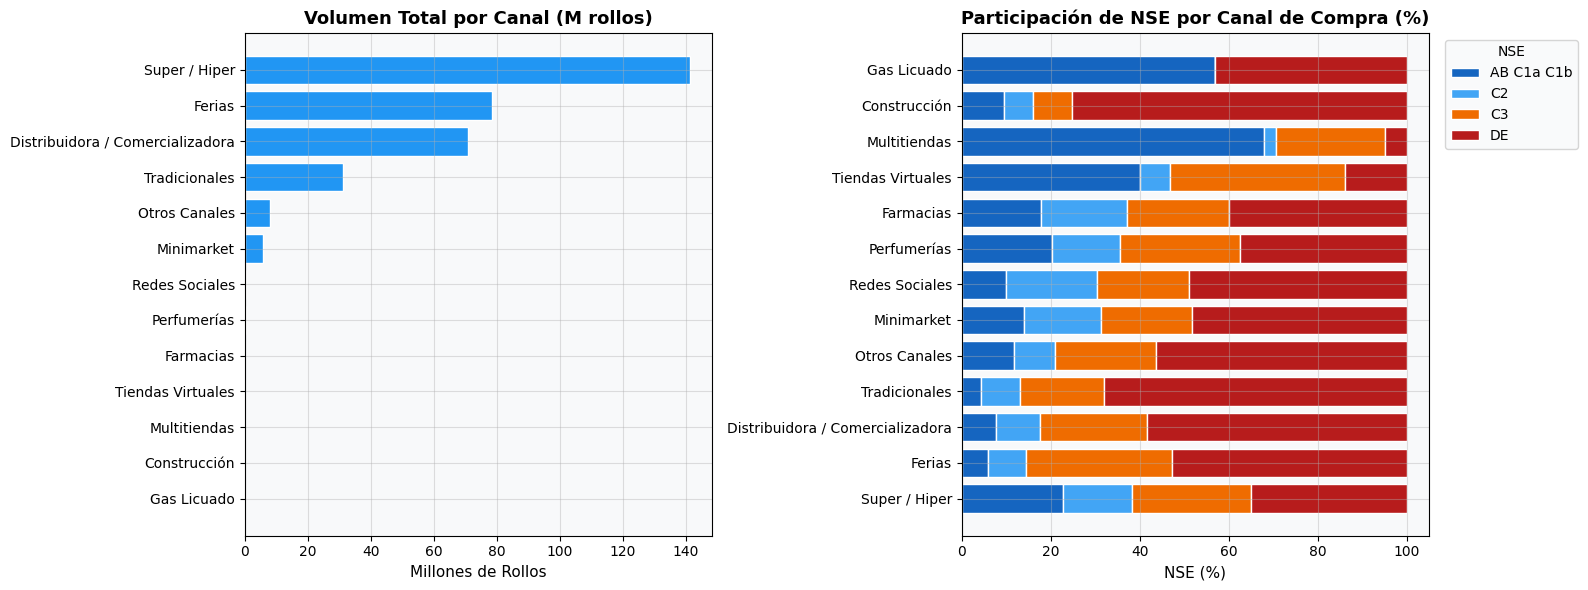

In [10]:
#  Distribución de volumen por canal y NSE 
canal_nse = df.groupby(['Tipo_Canal', 'NSE'])['Vol_Expandido'].sum().reset_index()
pivot_cn = canal_nse.pivot_table(
    index='Tipo_Canal', columns='NSE', values='Vol_Expandido', aggfunc='sum'
).fillna(0)

# Normalizar a participación de volumen por canal
pivot_cn_pct = pivot_cn.div(pivot_cn.sum(axis=1), axis=0) * 100
pivot_cn_pct = pivot_cn_pct.loc[pivot_cn.sum(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  Volumen absoluto por canal
vol_canal = df.groupby('Tipo_Canal')['Vol_Expandido'].sum().sort_values(ascending=True)
axes[0].barh(vol_canal.index, vol_canal.values/1e6, color=Paleta_Colores[0], edgecolor='white')
axes[0].set_title('Volumen Total por Canal (M rollos)', fontweight='bold')
axes[0].set_xlabel('Millones de Rollos')

#  Participación de NSE dentro de cada canal
NSE_ORDEN = ['AB C1a C1b', 'C2', 'C3', 'DE']
NSE_COLORES = ['#1565C0', '#42A5F5', '#EF6C00', '#B71C1C']
bottom = np.zeros(len(pivot_cn_pct))
for nse, color in zip(NSE_ORDEN, NSE_COLORES):
    if nse in pivot_cn_pct.columns:
        axes[1].barh(pivot_cn_pct.index, pivot_cn_pct[nse],
                     left=bottom, label=nse, color=color, edgecolor='white')
        bottom += pivot_cn_pct[nse].values
axes[1].set_title('Participación de NSE por Canal de Compra (%)', fontweight='bold')
axes[1].set_xlabel('NSE (%)')
axes[1].legend(title='NSE', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

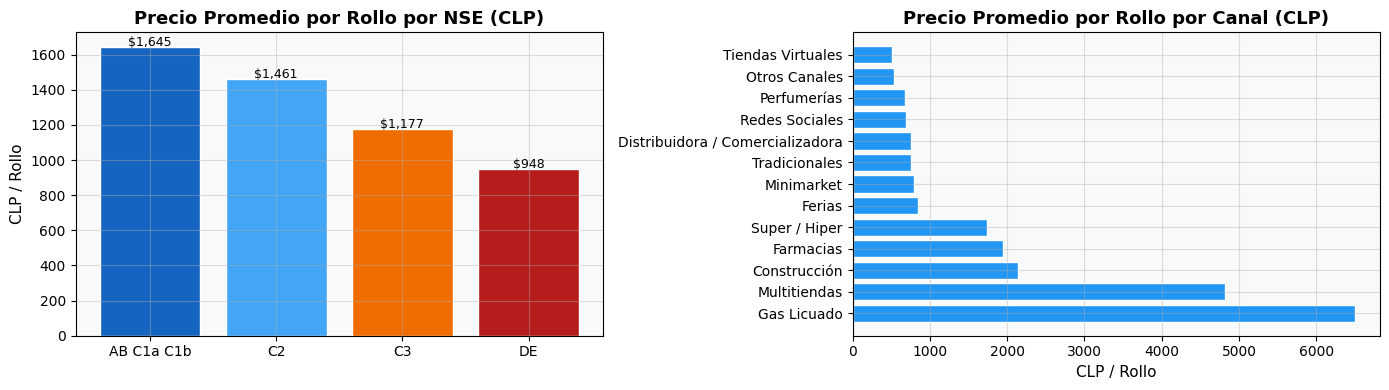

In [11]:
# Precio promedio por rollo: NSE y Canal
precio_nse = (df.groupby('NSE')
                .apply(lambda x: (x['Preco_Total'].sum() / x['Quantidade'].sum()))
                .round(0).reset_index())
precio_nse.columns = ['NSE', 'Precio_x_Rollo_CLP']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(precio_nse['NSE'], precio_nse['Precio_x_Rollo_CLP'],
            color=NSE_COLORES, edgecolor='white')
axes[0].set_title('Precio Promedio por Rollo por NSE (CLP)', fontweight='bold')
axes[0].set_ylabel('CLP / Rollo')
for i, row in precio_nse.iterrows():
    axes[0].text(i, row['Precio_x_Rollo_CLP'] + 5, f"${row['Precio_x_Rollo_CLP']:,.0f}",
                 ha='center', fontsize=9)

precio_canal = (df.groupby('Tipo_Canal')
                  .apply(lambda x: (x['Preco_Total'].sum() / x['Quantidade'].sum()))
                  .sort_values(ascending=False).round(0))
axes[1].barh(precio_canal.index, precio_canal.values, color=Paleta_Colores[0], edgecolor='white')
axes[1].set_title('Precio Promedio por Rollo por Canal (CLP)', fontweight='bold')
axes[1].set_xlabel('CLP / Rollo')

plt.tight_layout()
plt.show()

In [12]:
# Test estadístico: ¿El precio por rollo difiere significativamente entre NSE?
# ANOVA one-way
grupos = [df[df['NSE'] == nse]['Precio_Unitario'].dropna().values
          for nse in df['NSE'].unique()]
f_stat, p_valor = stats.f_oneway(*grupos)
print("ANOVA — Precio por Rollo por NSE")
print(f"F-statistic: {f_stat:.2f}")
print(f"p-valor:     {p_valor:.4f}")
print(f"Conclusión:  {'Diferencia estadísticamente significativa (p < 0.05)' if p_valor < 0.05 else 'Sin diferencia significativa'}")

# Test Chi-cuadrado: Independencia entre NSE y Canal
tabla_contingencia = pd.crosstab(df['NSE'], df['Tipo_Canal'])
chi2, p_chi, dof, expected = chi2_contingency(tabla_contingencia)
print(f"\n Chi-cuadrado — Asociación NSE × Canal")
print(f"Chi²: {chi2:.2f} | df: {dof} | p-valor: {p_chi:.4e}")
print(f"Conclusión: {'NSE y Canal NO son independientes — existe asociación significativa' if p_chi < 0.05 else 'Sin asociación'}")

ANOVA — Precio por Rollo por NSE
F-statistic: 1394.01
p-valor:     0.0000
Conclusión:  Diferencia estadísticamente significativa (p < 0.05)

 Chi-cuadrado — Asociación NSE × Canal
Chi²: 8762.74 | df: 36 | p-valor: 0.0000e+00
Conclusión: NSE y Canal NO son independientes — existe asociación significativa


- **El precio por rollo varía significativamente por NSE:** Los hogares de NSE alto (AB/C1) pagan considerablemente más por rollo que los segmentos bajos (C3/DE). El mercado está segmentado en dos niveles claros.
- **Implicancia para la distribución:** Los supermercados e hipermercados concentran la compra de los segmentos medios-altos, mientras que los canales tradicionales y mayoristas son más relevantes para NSE bajo, las estrategias de distribución deben ser diferenciadas por canal.
- **Canal y NSE están estructuralmente asociados:** Los hogares no eligen canal de forma aleatoria, la distribución de NSE varía significativamente según el canal, lo que implica que la estrategia de distribución de una marca define indirectamente a qué segmento socioeconómico llega.

## 7. Modelo Predictivo de Gasto por Hogar

In [13]:
# Features de nivel hogar para predecir gasto anual
hogar_feats = df.groupby('IdDomicilio').agg(
    NSE            = ('NSE', 'first'),
    Region         = ('Region', 'first'),
    Canal_Principal= ('Tipo_Canal', lambda x: x.mode()[0]),
    Gasto_Total    = ('Preco_Total', 'sum'),
    Frecuencia     = ('IdDomicilio', 'count'),
    Vol_Total      = ('Quantidade', 'sum'),
    Precio_Prom    = ('Precio_Unitario', 'mean'),
    Fabricantes    = ('Fabricante', 'nunique'),
    Marcas         = ('Marca', 'nunique'),
    Meses_Activo   = ('YearMonth', 'nunique'),
).reset_index()

# Encoding
le = LabelEncoder()
for col in ['NSE', 'Region', 'Canal_Principal']:
    hogar_feats[col + '_enc'] = le.fit_transform(hogar_feats[col].astype(str))

feature_cols = ['NSE_enc', 'Region_enc', 'Canal_Principal_enc',
                'Frecuencia', 'Vol_Total', 'Precio_Prom',
                'Fabricantes', 'Marcas', 'Meses_Activo']
target = 'Gasto_Total'

X = hogar_feats[feature_cols].fillna(0)
y = np.log1p(hogar_feats[target])  # log-transform para normalizar

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

# CV score
cv_scores = cross_val_score(gb, X, y, cv=5, scoring='r2')

print("MODELO: Gradient Boosting — Gasto por Hogar")
print(f"R² Test:           {r2_score(y_test, y_pred):.4f}")
print(f"MAE Test (log):    {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R² CV (5-fold):    {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

MODELO: Gradient Boosting — Gasto por Hogar
R² Test:           0.9768
MAE Test (log):    0.1135
R² CV (5-fold):    0.9675 ± 0.0044


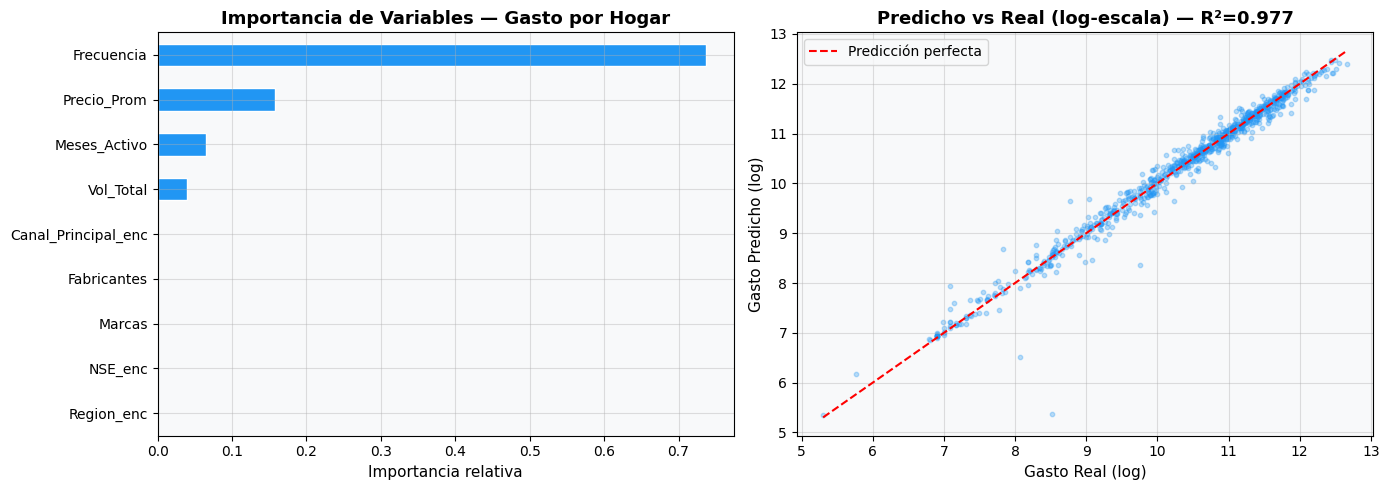

In [14]:
# Feature importance 
importances = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Importancia
importances.plot(kind='barh', ax=axes[0], color=Paleta_Colores[0], edgecolor='white')
axes[0].set_title('Importancia de Variables — Gasto por Hogar', fontweight='bold')
axes[0].set_xlabel('Importancia relativa')

# Predicted vs Actual
axes[1].scatter(y_test, y_pred, alpha=0.3, color=Paleta_Colores[0], s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_title(f'Predicho vs Real (log-escala) — R²={r2_score(y_test, y_pred):.3f}', fontweight='bold')
axes[1].set_xlabel('Gasto Real (log)')
axes[1].set_ylabel('Gasto Predicho (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

- **El comportamiento pasado predice el gasto mejor que el perfil:** Las variables más importantes son volumen total comprado, frecuencia de visita y meses activos, NSE y región tienen un rol secundario como moduladores, los hogares son altamente predecibles en esta categoría.
- **Aplicación inmediata para segmentación predictiva:** Este modelo puede usarse directamente para scoring de hogares, identificación de compradores de alto valor potencial y priorización de campañas de retención y activación.
- **Hallazgo estratégico clave:** Lo que más predice el gasto no es quién eres (perfil sociodemográfico) sino cómo has comprado (comportamiento histórico), esto tiene implicanciones directas para estrategias.

## 8. Sistema de Alertas Estadísticas

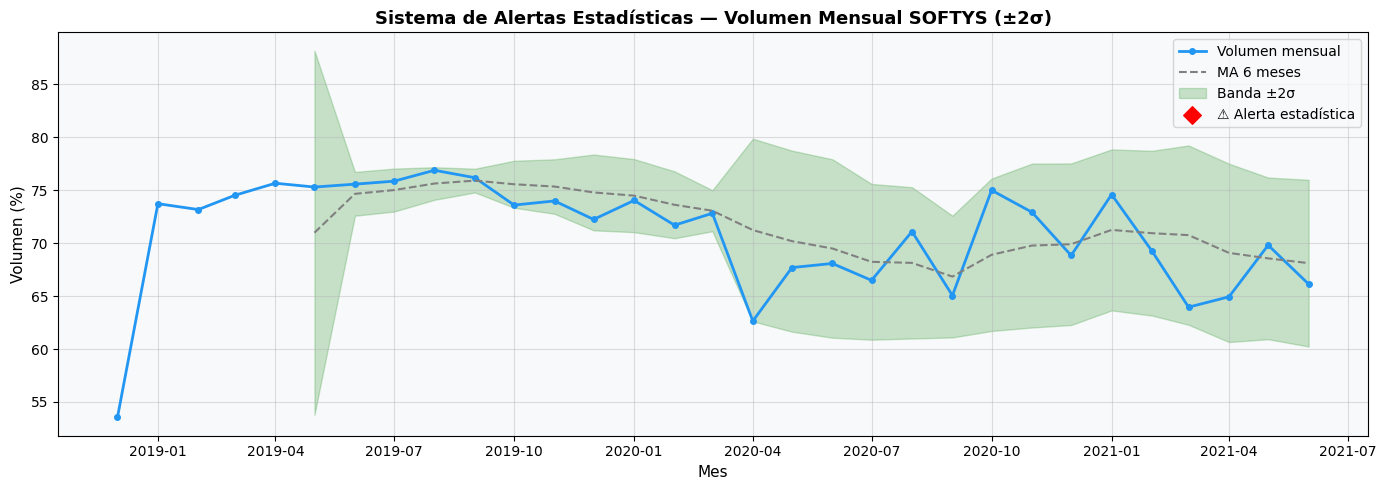

Meses en alerta estadística: 0 de 31


In [15]:
# ── Sistema de Bandas de Control
# Aplicado al volumen mensual del fabricante softys

FABRICANTE_FOCAL = 'SOFTYS'
WINDOW = 6

serie_volumen = df.groupby(['YearMonth', 'Fabricante'])['Vol_Expandido'].sum()
total_mes     = df.groupby('YearMonth')['Vol_Expandido'].sum()

volumen_focal = (serie_volumen.xs(FABRICANTE_FOCAL, level='Fabricante') /
                 total_mes * 100).reset_index()
volumen_focal.columns = ['YearMonth', 'Volumen']
volumen_focal['YM_dt'] = volumen_focal['YearMonth'].dt.to_timestamp()

volumen_focal['MA']   = volumen_focal['Volumen'].rolling(WINDOW).mean()
volumen_focal['STD']  = volumen_focal['Volumen'].rolling(WINDOW).std()
volumen_focal['UCL']  = volumen_focal['MA'] + 2 * volumen_focal['STD']
volumen_focal['LCL']  = volumen_focal['MA'] - 2 * volumen_focal['STD']
volumen_focal['ALERT']= (volumen_focal['Volumen'] < volumen_focal['LCL']) | \
                        (volumen_focal['Volumen'] > volumen_focal['UCL'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(volumen_focal['YM_dt'], volumen_focal['Volumen'], color=Paleta_Colores[0],
        linewidth=2, marker='o', markersize=4, label='Volumen mensual')
ax.plot(volumen_focal['YM_dt'], volumen_focal['MA'], color='gray',
        linewidth=1.5, linestyle='--', label=f'MA {WINDOW} meses')
ax.fill_between(volumen_focal['YM_dt'], volumen_focal['LCL'], volumen_focal['UCL'],
                alpha=0.2, color='green', label='Banda ±2σ')


alertas = volumen_focal[volumen_focal['ALERT']]
ax.scatter(alertas['YM_dt'], alertas['Volumen'], color='red', zorder=5,
           s=80, label='⚠ Alerta estadística', marker='D')

ax.set_title(f'Sistema de Alertas Estadísticas — Volumen Mensual {FABRICANTE_FOCAL} (±2σ)',
             fontweight='bold')
ax.set_ylabel('Volumen (%)')
ax.set_xlabel('Mes')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Meses en alerta estadística: {volumen_focal['ALERT'].sum()} de {len(volumen_focal)}")

In [16]:
# ── Resumen de KPIs y alertas por fabricante
TOP_FABS = top_fab[:5]
alertas_resumen = []

for fab in TOP_FABS:
    try:
        sf = (serie_volumen.xs(fab, level='Fabricante') / total_mes * 100).reset_index()
        sf.columns = ['YearMonth', 'Volumen_Pct']
        sf['MA']  = sf['Volumen_Pct'].rolling(WINDOW).mean()
        sf['STD'] = sf['Volumen_Pct'].rolling(WINDOW).std()
        sf['UCL'] = sf['MA'] + 2 * sf['STD']
        sf['LCL'] = sf['MA'] - 2 * sf['STD']
        n_alert = ((sf['Volumen_Pct'] < sf['LCL']) | (sf['Volumen_Pct'] > sf['UCL'])).sum()
        trend = 'Creciente' if sf['Volumen_Pct'].iloc[-3:].mean() > sf['Volumen_Pct'].iloc[-9:-3].mean() else 'Decreciente'
        alertas_resumen.append({'Fabricante': fab, 'Alertas': n_alert,
                                'Volumen_Prom_%': sf['Volumen_Pct'].mean().round(2),
                                'Tendencia_Reciente': trend})
    except:
        continue

print("\n RESUMEN DE PARTICIPACIÓN DE VOLUMEN Y ALERTAS POR FABRICANTE")
display(pd.DataFrame(alertas_resumen).sort_values('Alertas', ascending=False).reset_index(drop=True))


 RESUMEN DE PARTICIPACIÓN DE VOLUMEN Y ALERTAS POR FABRICANTE


,Fabricante,Alertas,Volumen_Prom_%,Tendencia_Reciente
0,SOFTYS,0,70.82,Decreciente
1,KIMBERLY-CLARK,0,8.93,Creciente
2,PISA,0,5.46,Decreciente
3,LIDER,0,3.29,Decreciente
4,FPC TISSUE,0,3.74,Creciente


- **0 alertas disparadas en 31 meses para los 5 fabricantes top:** El sistema de bandas de control ±2σ no detectó ningún mes estadísticamente anómalo, pero si hay que hacer seguimiento a la tendencia reciente para controlar las futuras alertas.
- **La tendencia decreciente no activa alertas de corto plazo:** Por ejemplo SOFTYS perdió 5% de participación en 12 meses sin que ningún mes individual saliera de las bandas de control, el riesgo real es la tendencia decreciente a mediano plazo, por lo cual es recomendable complementar las alertas de corto plazo (±2σ mensual) con un monitor de tendencia de mediano plazo por ejemplo, una regresión lineal.
- **Kimberly-Clark y FPC Tissue:** Tendencia creciente sostenida con 0 alertas, un crecimiento gradual y consistente.